In [ ]:
!pip install kmodes

In [ ]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


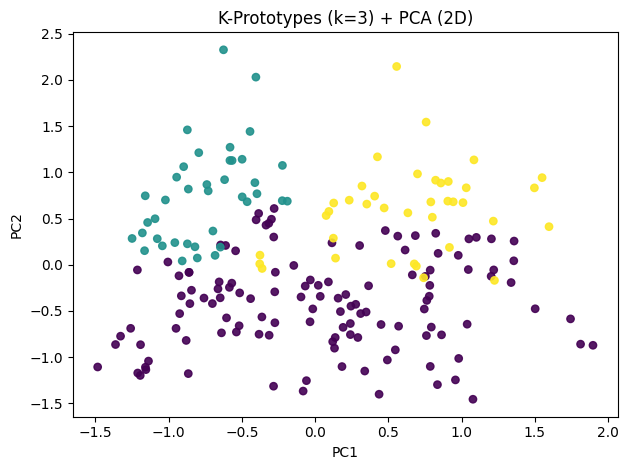

In [ ]:

df0=df.drop(columns=[c for c in df.columns if c.lower() in ("id","customerid")], errors="ignosre")
cat_cols = df0.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = df0.select_dtypes(include=[np.number]).columns.tolist()

if num_cols:
  df[num_cols]=SimpleImputer(strategy="median").fit_transform(df[num_cols])
if cat_cols:
  df[cat_cols]=SimpleImputer(strategy="most_frequent").fit_transform(df[cat_cols].astype("object"))

for c in cat_cols:df[c]=df[c].astype(str)
for c in num_cols:df[c]=df[c].astype(float)


k=3
X_mix=df.values
cat_idx = [df.columns.get_loc(c) for c in cat_cols]
kproto = KPrototypes(n_clusters=k, init="Huang", verbose=0)
labels = kproto.fit_predict(X_mix, categorical=cat_idx)

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=False) if cat_cols else df.copy()
X_scaled = RobustScaler().fit_transform(df_enc.values)
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=28, alpha=0.9)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"K-Prototypes (k={k}) + PCA (2D)")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


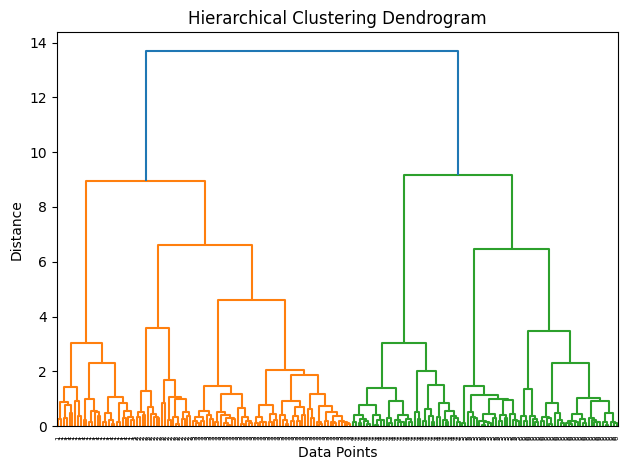

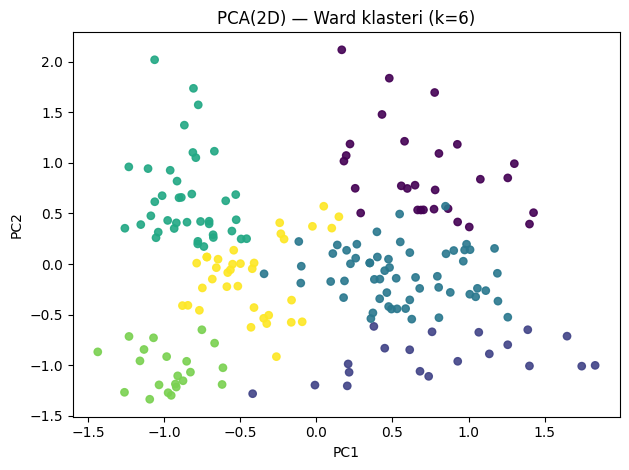

In [ ]:
df=df.drop(columns=[c for c in df.columns if c.lower() in ("id","customerid")], errors="ignosre")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()


X=SimpleImputer(strategy="median").fit_transform(df[num_cols])
X = RobustScaler().fit_transform(X)
Z = linkage(X, method="ward")
t=6
labels = fcluster(Z, t=t, criterion="maxclust")

plt.figure()
dendrogram(Z, labels=labels)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


X2 = PCA(n_components=2, random_state=42).fit_transform(X)
plt.figure()
plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=28, alpha=0.9)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"PCA(2D) — Ward klasteri (k={t})")
plt.tight_layout()
plt.show()




In [ ]:
out = df0.copy()
out[f"ward_k{6}"] = labels
out.to_csv("izlaz.csv", index=False)
#

[[0.         0.72645062 0.83428439 ... 1.04558688 1.06503972 1.1024721 ]
 [0.         0.15471875 0.37889537 ... 0.70832459 0.93713825 1.07609558]
 [0.         0.74276462 1.04208975 ... 1.23672966 1.2701344  1.30414917]
 ...
 [0.         0.39489458 0.72990104 ... 1.10651744 1.18412387 1.38352275]
 [0.         0.70932342 1.27507059 ... 1.60352919 1.64941    1.66383806]
 [0.         0.39489458 1.06598875 ... 1.42115428 1.46958443 1.51288748]]


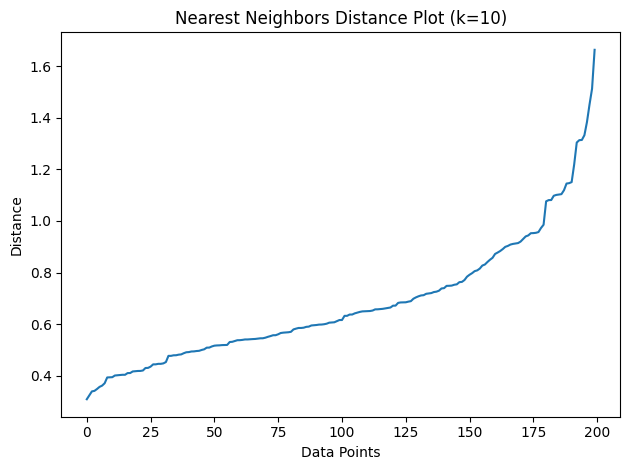

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

df0 = pd.read_csv('/content/Mall_Customers.csv')
df=df.drop(columns=[c for c in df.columns if c.lower() in ("id","customerid")], errors="ignore")

cat = df.select_dtypes(include=["object","category"]).columns
num = df.select_dtypes(include=[np.number]).columns


df[num] = SimpleImputer(strategy="median").fit_transform(df[num])
df[cat] = SimpleImputer(strategy="most_frequent").fit_transform(df[cat].astype("object"))
X = pd.get_dummies(df, columns=cat, drop_first=False).values
X = RobustScaler().fit_transform(X)

min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
#distances, indices = nbrs.kneighbors(X)
print(nbrs.kneighbors(X)[0][:,:])

dists = np.sort(nbrs.kneighbors(X)[0][:,-1])

plt.figure()
plt.plot(dists)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title(f"Nearest Neighbors Distance Plot (k={min_samples})")
plt.tight_layout()
plt.show()


[ 1  1 -1  0  0  0  0  0 -1  0 -1  0  0  0 -1  1  0  1  1  0  1  1  0  1
  0  1  0  1  0  0 -1  0  1  1  0  0  0  0  0  0  0  1  1  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  1  1  0  0  1  1  0  0  1  0  1  0
  0  0  1  1  0  1  0  0  1  1  1  0  0  1  0  0  0  0  0  1  1  0  0  1
  0  0  1  1  0  0  1  1  1  0  0  1  1  1  1  0  0  1  0  0  0  0  0  0
  1  0  0  1  0  0  1  1  1  1  1  1  0  0  1  0  0  1  1  0  0  1  0  0
  1  1  1  0  0  1  1  1  0  0  0  0  1  0  1  0  0  0  1  0  1  0  1  0
  0  1  1  1  1  1  0  0  1  1  1  1  0  0  1  0  0  1  0  1  0  0  0  0
  1  0  0  0  0 -1 -1 -1]


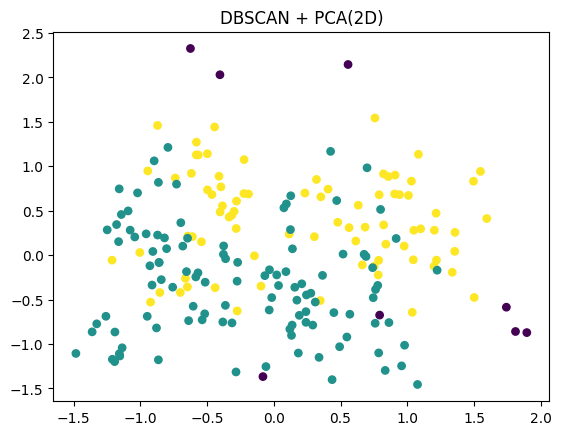

Broj klastera: 2 Udio šuma: 0.04


In [ ]:
db = DBSCAN(eps=0.9, min_samples=10).fit(X)
labels = db.labels_
print(labels)


X2 = PCA(n_components=2, random_state=42).fit_transform(X)
plt.scatter(X2[:,0], X2[:,1], c=labels, s=28); plt.title("DBSCAN + PCA(2D)"); plt.show()
print("Broj klastera:", len(set(labels)-{-1}), "Udio šuma:", np.mean(labels==-1))

